In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course.
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
np.random.seed(0)


In [4]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
!ls *

drive:
MyDrive  Shareddrives

sample_data:
anscombe.json		      mnist_test.csv
california_housing_test.csv   mnist_train_small.csv
california_housing_train.csv  README.md


In [6]:
root_folder = '/content/drive/MyDrive/OIST-mini-course'
!ls $root_folder

dest_folder = os.path.join(root_folder, 'dataset_for_classification')
if not os.path.isdir(dest_folder):
    zip_file = os.path.join(root_folder, 'dataset_for_classification.zip')
    !echo $zip_file
    !echo $dest_folder
    !unzip $zip_file -d $root_folder

cls_train.pkl
cls_val.pkl
code001_part-A_setup.ipynb
code001_part-B_setup.ipynb
code001_setup_readme.docx
code001_setup_readme.pdf
code002_data_prep_NN.ipynb
code003_LogReg.ipynb
code004_DNN_scratch.ipynb
code005_part-A_detection_dataPrep.ipynb
code005_part-B_pollen_detection_model_design.ipynb
code005_part-C_pollen_detection_training.ipynb
code006_part-A_DNN_finetune.ipynb
code006_part-B_pollen_detection_finetune.ipynb
dataset_for_classification
dataset_for_classification.zip
dataset_for_detection
dataset_for_detection.zip
det_trainval_splits.pkl
meta_detection.pkl
slides
test-image.jpg
test-image-sharpened.jpg


# Split the dataset into a training set and a validation set

In [7]:
source_folder = os.path.join(root_folder, 'dataset_for_classification')
filename = 'meta_classification.txt'
train_portion = 0.8 # using 80% data for training
val_portion = 1-train_portion # using the rest 20% data for validation


train_imgpathlist = []
train_labellist = []
val_imgpathlist = []
val_labellist = []

In [8]:
list_speciesnames = os.listdir(os.path.join(source_folder))

labelID = -1
for cur_species in list_speciesnames:
    labelID += 1
    exampleIDs = os.listdir(os.path.join(source_folder, cur_species))
    tmpList = []
    permutedInds = np.random.permutation(len(exampleIDs))
    trainNum = round(len(exampleIDs)*train_portion)
    # valNum = len(exampleIDs)-trainNum

    # train data
    for i in range(len(permutedInds)):
        curIdx = permutedInds[i]

        if i<trainNum:
            train_imgpathlist += [os.path.join(source_folder, cur_species, exampleIDs[curIdx])]
            train_labellist += [labelID]
        else:
            val_imgpathlist += [os.path.join(source_folder, cur_species, exampleIDs[curIdx])]
            val_labellist += [labelID]

    print('processing of ' + cur_species +' is finished')

processing of 016_acy is finished
processing of 017_alc is finished
processing of 020_alu is finished
processing of 038_cec is finished
processing of 049_cor is finished
processing of 088_oen is finished
processing of 085_mor is finished
processing of 031_ast is finished
processing of 079_lyc is finished
processing of 062_euc is finished
processing of 114_vir is finished
processing of 068_gen is finished
processing of 044_chc is finished
processing of 076_ixo is finished
processing of 074_hyr is finished
processing of 082_mic is finished
processing of 113_unc is finished
processing of 066_fra is finished
processing of 086_mrp is finished
processing of 102_sab is finished
processing of 024_anx is finished
processing of 096_prt is finished
processing of 058_did is finished
processing of 097_pse is finished


In [55]:
len(train_labellist), len(val_labellist), np.unique(np.asarray(train_labellist)), np.unique(np.asarray(val_labellist))

(480,
 120,
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23]),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23]))

In [10]:
filename_train = os.path.join(root_folder, 'cls_train.pkl')
filename_val = os.path.join(root_folder, 'cls_val.pkl')
print(filename_train, filename_val)

/content/drive/MyDrive/OIST-mini-course/cls_train.pkl /content/drive/MyDrive/OIST-mini-course/cls_val.pkl


In [11]:
with open(filename_train, 'wb') as file:
    pickle.dump({'train_imgpathlist':train_imgpathlist,
                 'train_labellist':train_labellist}, file)

In [12]:
with open(filename_val, 'wb') as file:
    pickle.dump({'val_imgpathlist':val_imgpathlist,
                 'val_labellist':val_labellist}, file)

# Nearest Neighbor Classifier

In [14]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [15]:
trainset_info.keys(), valset_info.keys()

(dict_keys(['train_imgpathlist', 'train_labellist']),
 dict_keys(['val_imgpathlist', 'val_labellist']))

In [16]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [17]:
numClasses

24

In [18]:
train_imgs = []
val_imgs = []

for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    train_imgs += [im.astype(np.float32)]

for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    val_imgs += [im.astype(np.float32)]

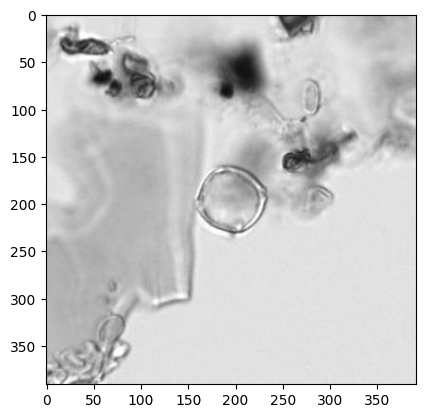

In [19]:
# visualize a random image
idx = 10
img = val_imgs[0]
plt.imshow(img.astype(np.uint8))

In [20]:
def NearestNeighbor(Database, test_img):
    distanceList = []
    for i in range(len(Database)):
        curExample = Database[i]
        tmp = np.abs(curExample - test_img)
        distanceList += [tmp.sum()]
    return distanceList

In [21]:
predList = []
for i in range(len(val_imgs)):
    cur_img = val_imgs[i]
    distanceList = NearestNeighbor(train_imgs, cur_img)
    distanceList = np.array(distanceList)
    targetIdx = np.argmin(distanceList)
    predLabel = train_labellist[targetIdx]
    predList += [predLabel]

    if i%10==0:
        print('%d/%d...' %(i, len(val_imgs)))

0/120...
10/120...
20/120...
30/120...
40/120...
50/120...
60/120...
70/120...
80/120...
90/120...
100/120...
110/120...


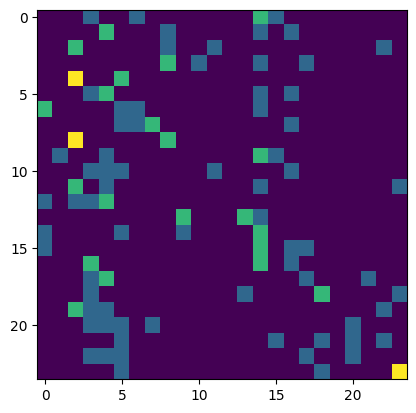

In [22]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [23]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.158


## using sklearn to run Nearest Neighbor and K Nearest Neighbor

In [108]:
from sklearn.neighbors import KNeighborsClassifier

X_train = np.asarray(train_imgs)
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0
y_train = np.asarray(train_labellist)

clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
clf.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=1)

In [109]:
X_train.shape, y_train.shape

((480, 458643), (480,))

In [110]:
X_val = np.asarray(val_imgs)
X_val = X_val.reshape(X_val.shape[0], -1) / 255.0
X_val.shape

(120, 458643)

In [111]:
predictions = clf.predict(X_val)

In [112]:
predictions

array([15,  6,  3, 14, 14, 16,  4,  8, 14,  4,  2,  2, 11,  8, 22, 14, 17,
        8,  8, 10,  2,  5,  2,  2,  5, 16, 14,  4,  4,  3,  0,  0, 14,  5,
        6,  6,  7, 16,  5,  7,  8,  8,  2,  2,  2, 14, 14,  1,  4, 15,  4,
       16,  5, 11,  3,  2, 23,  4,  2, 14,  2,  4,  0,  4,  3,  9, 13, 14,
       13,  9, 14,  0,  9,  5, 14, 14, 14,  0, 16, 17,  3, 14, 16, 14,  3,
       21, 17,  4,  4,  3, 23,  3, 18, 13, 18,  3,  2,  4,  2, 22,  5,  7,
        4, 20,  3, 15, 20,  5, 18, 22, 20, 17,  5,  3,  4,  5, 23, 23, 18,
       23])

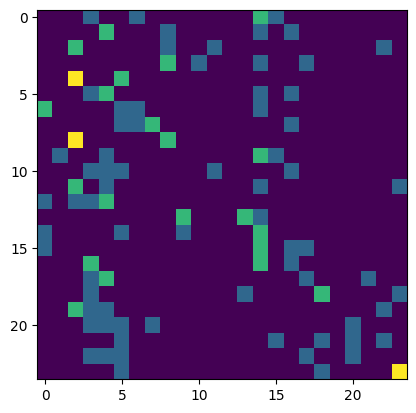

In [113]:
conf = sklearn.metrics.confusion_matrix(np.asarray(val_labellist), predictions, normalize='true')
plt.imshow(conf)

In [114]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.158


In [115]:
per_class_acc

array([0. , 0. , 0.4, 0. , 0. , 0. , 0.2, 0.4, 0.4, 0. , 0. , 0. , 0. ,
       0.4, 0.4, 0. , 0.2, 0.2, 0.4, 0. , 0.2, 0. , 0. , 0.6])

In [116]:
np.asarray(val_labellist), predictions

(array([ 0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  3,  3,
         3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  6,  6,  6,  6,
         6,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9, 10,
        10, 10, 10, 10, 11, 11, 11, 11, 11, 12, 12, 12, 12, 12, 13, 13, 13,
        13, 13, 14, 14, 14, 14, 14, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16,
        17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 19, 19, 19, 19, 19, 20, 20,
        20, 20, 20, 21, 21, 21, 21, 21, 22, 22, 22, 22, 22, 23, 23, 23, 23,
        23]),
 array([15,  6,  3, 14, 14, 16,  4,  8, 14,  4,  2,  2, 11,  8, 22, 14, 17,
         8,  8, 10,  2,  5,  2,  2,  5, 16, 14,  4,  4,  3,  0,  0, 14,  5,
         6,  6,  7, 16,  5,  7,  8,  8,  2,  2,  2, 14, 14,  1,  4, 15,  4,
        16,  5, 11,  3,  2, 23,  4,  2, 14,  2,  4,  0,  4,  3,  9, 13, 14,
        13,  9, 14,  0,  9,  5, 14, 14, 14,  0, 16, 17,  3, 14, 16, 14,  3,
        21, 17,  4,  4,  3, 23,  3, 18, 13, 18,  3,  2,  4,  2, 22,  5,  7

# Using better features

In [180]:
X_train = np.asarray(train_imgs)
X_train = X_train[:,
                  X_train.shape[1]//2-100:X_train.shape[1]//2+100,
                  X_train.shape[2]//2-100:X_train.shape[2]//2+100,
                  0] # suppose the new feature is a 100x100 square region in image center
X_train = X_train.reshape(X_train.shape[0], -1) / 255.0 - 0.5


# do the same feature extraction for validation images
X_val = np.asarray(val_imgs)
X_val = X_val[:,
                  X_val.shape[1]//2-100:X_val.shape[1]//2+100,
                  X_val.shape[2]//2-100:X_val.shape[2]//2+100,
                  0]
X_val = X_val.reshape(X_val.shape[0], -1) / 255.0 - 0.5

print(X_train.shape, X_val.shape)

(480, 40000) (120, 40000)


In [181]:
clf = KNeighborsClassifier(n_neighbors=1, metric='manhattan')
clf.fit(X_train, y_train)

KNeighborsClassifier(metric='manhattan', n_neighbors=1)

In [182]:
predictions = clf.predict(X_val)

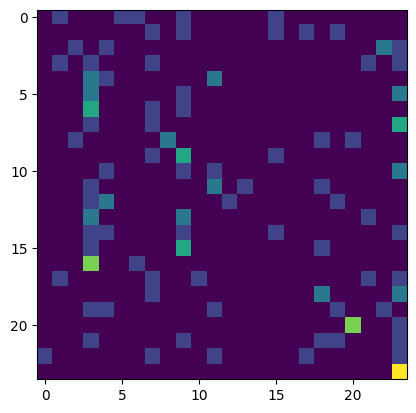

In [183]:
conf = sklearn.metrics.confusion_matrix(np.asarray(val_labellist), predictions, normalize='true')
plt.imshow(conf)

In [184]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.200


### vary K and test K-NN

In [ ]:
clf = KNeighborsClassifier(n_neighbors=3, metric='manhattan')
clf.fit(X_train, y_train)

In [243]:
predictions = clf.predict(X_val)

In [ ]:
conf = sklearn.metrics.confusion_matrix(np.asarray(val_labellist), predictions, normalize='true')
plt.imshow(conf)

In [ ]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())